### Training a model on the US Army data. ~100 features => Weight

In [ ]:
import os

from mlsuite.reg import Regression, GDConfig, OptimizationMethod
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import kagglehub

GRAD = OptimizationMethod.GRAD

In [2]:
DATA_DIR = kagglehub.dataset_download("seshadrikolluri/ansur-ii")
print("Path to dataset files:", DATA_DIR)

Path to dataset files: C:\Users\PC_9986\.cache\kagglehub\datasets\seshadrikolluri\ansur-ii\versions\1


In [3]:
# Parse.
reader = pd.concat(
    [
        pd.read_csv(os.path.join(DATA_DIR, "ANSUR II MALE Public.csv"), encoding="latin1"),
        pd.read_csv(os.path.join(DATA_DIR, "ANSUR II FEMALE Public.csv"))
    ],
    axis=0,
    ignore_index=True
)

In [4]:
# Remove null points.
reader = reader[reader["weightkg"] > 0.0].reset_index(drop=True)

# Look at our label data.
weights = reader["weightkg"].to_numpy(dtype=np.int32)

weights.min(), weights.max(), weights.mean(), weights.std()

(np.int32(358),
 np.int32(1442),
 np.float64(797.0939353988134),
 np.float64(156.51526577526704))

In [5]:
# Parse parameters.
# Map 'Male' to 0 and 'Female' to 1
reader['Gender'] = reader['Gender'].map({'Male': 0, 'Female': 1})

labels = reader["weightkg"].to_numpy(dtype=np.int32)

# ! See if "Component" has an effect later.
reader = reader.drop(
    columns=["subjectid", "SubjectId", "weightkg", "Weightlbs", "Ethnicity", "Date", "Component", "WritingPreference", "PrimaryMOS", "Branch", "Installation"],
    errors="ignore"
)

# Factorize: set a specific number for each birth location.
reader["SubjectsBirthLocation"] = pd.factorize(reader["SubjectsBirthLocation"])[0]

dataset = reader.to_numpy(dtype=np.float64)

# Scale data.
dataset = (dataset - dataset.mean(axis=0)) / dataset.std(axis=0)

In [6]:
# Divide the dataset into train/test.
X_train, X_test, y_train, y_test = train_test_split(dataset, labels, test_size=0.2, shuffle=True)

In [7]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4854, 98), (1214, 98), (4854,), (1214,))

In [8]:
# Linear Regression with GradientDescent lr=0.01 and niters=100000.
weights = np.random.randn(X_train.shape[1])

conf = GDConfig(lr=0.01, niters=10000, degree=1, use_bias=True, l2_coef=1e-03, normalize_data=True)
model = Regression(GRAD, gdconf=conf)
model.fit(X_train, y_train)

In [9]:
def calc_mse(y_true: np.ndarray, y_pred: np.ndarray):
    return np.sum(np.pow(y_true - y_pred, 2)) / y_true.shape[0]

y_pred = model.predict(X_test)
y_pred = y_pred.flatten()

Test Mean Squared Error (MSE): 268.36
Test Root Mean Squared Error (RMSE): 16.38 lbs


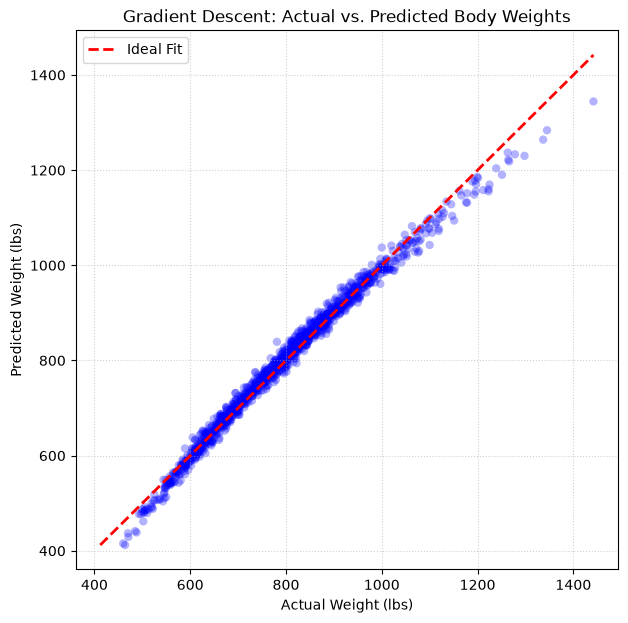

In [10]:
# 1. Calculate final test MSE using your function
test_mse = calc_mse(y_test, y_pred)
test_rmse = np.sqrt(test_mse)

print(f"Test Mean Squared Error (MSE): {test_mse:.2f}")
print(f"Test Root Mean Squared Error (RMSE): {test_rmse:.2f} lbs")

# 2. Visualize with a True vs. Predicted Scatter Plot
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.3, color="blue", edgecolors="none")

# Draw a ideal 45-degree reference line (where True = Predicted)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", lw=2, label="Ideal Fit")

plt.xlabel("Actual Weight (lbs)")
plt.ylabel("Predicted Weight (lbs)")
plt.title("Gradient Descent: Actual vs. Predicted Body Weights")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

In [11]:
# Mean Absolute Percentage Error
mape = 100 * np.sum(np.abs(y_pred - y_test) / y_test) / y_test.size
acc = 100 - mape

print(f"Model accuracy: {acc:.3f}%")

Model accuracy: 98.421%


#### Let's now look at the parameters.

In [18]:
weights = model.W.flatten()

bias = weights[0]
wmap = dict(zip(reader.columns, weights[1:]))

param_ranking = sorted(wmap, key=lambda k: wmap[k], reverse=True)

In [21]:
print("Parameters listed in descending order from the highest assigned weight: ", end="\n\t")
print("\n\t".join(param_ranking))

Parameters listed in descending order from the highest assigned weight: 
	chestcircumference
	waistcircumference
	calfcircumference
	buttockcircumference
	bicepscircumferenceflexed
	stature
	shouldercircumference
	thighcircumference
	neckcircumference
	lowerthighcircumference
	waistdepth
	cervicaleheight
	hipbreadthsitting
	acromialheight
	wristheight
	crotchheight
	suprasternaleheight
	thighclearance
	abdominalextensiondepthsitting
	crotchlengthomphalion
	acromionradialelength
	poplitealheight
	Gender
	neckcircumferencebase
	tenthribheight
	verticaltrunkcircumferenceusa
	forearmcircumferenceflexed
	forearmforearmbreadth
	forearmhandlength
	heelanklecircumference
	sittingheight
	chestdepth
	footbreadthhorizontal
	chestheight
	sleevelengthspinewrist
	elbowrestheight
	buttockpopliteallength
	anklecircumference
	wristcircumference
	biacromialbreadth
	buttockheight
	heelbreadth
	handcircumference
	buttockdepth
	lateralfemoralepicondyleheight
	palmlength
	interscyeii
	headbreadth
	waistbrea

In [ ]:
# Delete data so that one could see the results (you can remove this if you have 32Gb+ RAM).
del weights
del reader